Stage 1a — Data audit

Profile both source files before any analysis touches them: shape, coverage,
dtypes, missingness and duplicates.

In [2]:
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 50)

REPORTS = "results/reports"
FIGURES = "results/figures"
os.makedirs(REPORTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

CONFLICT_ONSET = pd.Timestamp("2026-03-16")

daily = pd.read_csv("datasets/processed/master_daily.csv", parse_dates=["date"]).set_index("date").sort_index()
weekly = pd.read_csv("datasets/processed/master_weekly.csv", parse_dates=["week_start"]).set_index("week_start").sort_index()

print("daily ", daily.shape, daily.index.min().date(), "..", daily.index.max().date())
print("weekly", weekly.shape, weekly.index.min().date(), "..", weekly.index.max().date())

daily  (382, 3) 2025-01-13 .. 2026-06-30
weekly (77, 4) 2025-01-13 .. 2026-06-29


Coverage, dtypes and missingness

In [4]:
def profile(frame, name):
    rows = []
    for col in frame.columns:
        s = frame[col]
        rows.append({
            "column": col,
            "dtype": str(s.dtype),
            "n": int(s.shape[0]),
            "nulls": int(s.isna().sum()),
            "null_pct": round(100 * float(s.isna().mean()), 2),
            "n_unique": int(s.nunique()),
            "min": s.min() if pd.api.types.is_numeric_dtype(s) else None,
            "max": s.max() if pd.api.types.is_numeric_dtype(s) else None,
        })
    out = pd.DataFrame(rows)
    print()
    print(name)
    print(out.to_string(index=False))
    return out

prof_daily = profile(daily, "master_daily.csv")
prof_weekly = profile(weekly, "master_weekly.csv")

print()
print("duplicate index values  daily:", int(daily.index.duplicated().sum()),
      " weekly:", int(weekly.index.duplicated().sum()))
print("index monotonic         daily:", daily.index.is_monotonic_increasing,
      " weekly:", weekly.index.is_monotonic_increasing)

gaps = daily.index.to_series().diff().dt.days.value_counts().sort_index()
print()
print("spacing between consecutive daily rows (days -> count):")
print(gaps.to_string())


master_daily.csv
         column   dtype   n  nulls  null_pct  n_unique        min        max
    brent_close float64 382      0       0.0       377    63.6220    99.2440
 rhetoric_index float64 382      0       0.0       374    -0.3224     0.9284
tanker_rate_usd float64 382      0       0.0       382 20972.6000 46290.9000

master_weekly.csv
                  column dtype  n  nulls  null_pct  n_unique  min  max
            acled_events int64 77      0       0.0        29    9   55
        acled_fatalities int64 77      0       0.0        35    2  102
acled_fatalities_revised int64 77      0       0.0        37    3  146
         hormuz_severity int64 77      0       0.0         5    0    4

duplicate index values  daily: 0  weekly: 0
index monotonic         daily: True  weekly: True

spacing between consecutive daily rows (days -> count):
date
1.0    305
3.0     76


Distributions

In [6]:
print(daily.describe().T.to_string())
print()
print(weekly.describe().T.to_string())

                 count          mean          std         min          25%          50%           75%         max
brent_close      382.0     77.662037     7.496323     63.6220     73.15825     76.46550     80.619500     99.2440
rhetoric_index   382.0      0.181360     0.223064     -0.3224      0.03080      0.15975      0.311775      0.9284
tanker_rate_usd  382.0  31029.959162  6354.115289  20972.6000  25192.90000  30975.40000  36462.325000  46290.9000

                          count       mean        std  min   25%   50%   75%    max
acled_events               77.0  23.467532  11.418573  9.0  16.0  19.0  24.0   55.0
acled_fatalities           77.0  25.116883  28.354418  2.0   9.0  13.0  19.0  102.0
acled_fatalities_revised   77.0  34.948052  38.750856  3.0  13.0  18.0  25.0  146.0
hormuz_severity            77.0   1.506494   1.021137  0.0   1.0   1.0   2.0    4.0


Sampling grain per column

A column that changes on fewer than half of its rows is forward-filled, not
daily. Treating it as daily inflates every sample size downstream.

In [8]:
from src.data.loaders import grain_report

weekly_ff = weekly.reindex(daily.index, method="ffill")
combined = daily.join(weekly_ff)
grain = grain_report(combined)
print(grain.to_string(index=False))
grain.to_csv(f"{REPORTS}/grain_report.csv", index=False)

print()
print("ACLED columns are weekly and forward-filled. They are tested at weekly")
print("frequency in the analysis notebook rather than resampled to daily.")

                  column  n_rows  n_update_events  change_rate                      grain  se_inflation
             brent_close     382              381        0.997                      daily          1.00
          rhetoric_index     382              381        0.997                      daily          1.00
         tanker_rate_usd     382              381        0.997                      daily          1.00
            acled_events     382               70        0.183 forward-filled (sub-daily)          2.34
        acled_fatalities     382               71        0.186 forward-filled (sub-daily)          2.32
acled_fatalities_revised     382               76        0.199 forward-filled (sub-daily)          2.24
         hormuz_severity     382               43        0.113 forward-filled (sub-daily)          2.98

ACLED columns are weekly and forward-filled. They are tested at weekly
frequency in the analysis notebook rather than resampled to daily.


Series plots

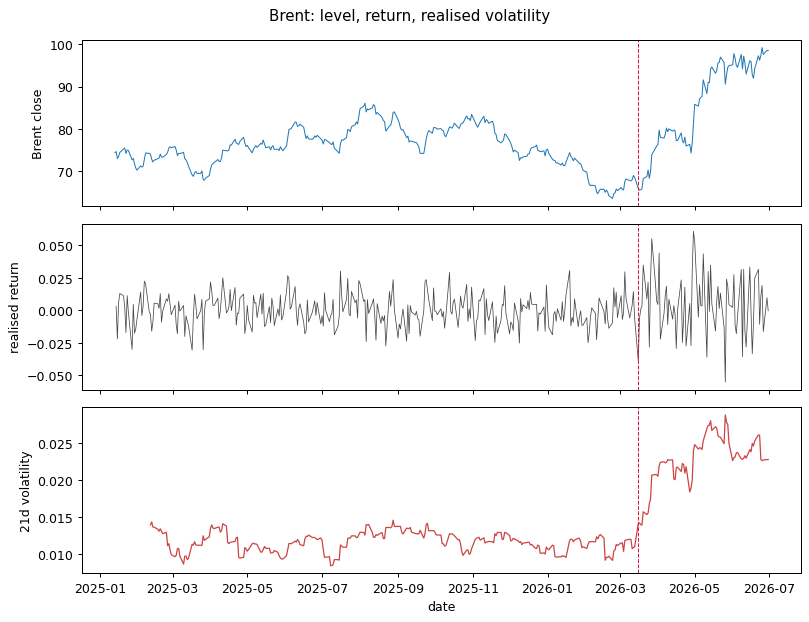

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
axes[0].plot(daily.index, daily["brent_close"], lw=.8)
axes[0].set_ylabel("Brent close")
axes[0].axvline(CONFLICT_ONSET, color="crimson", ls="--", lw=.8)
ret = np.log(daily["brent_close"]).diff()
axes[1].plot(daily.index, ret, lw=.6, color="#444")
axes[1].set_ylabel("realised return")
axes[1].axvline(CONFLICT_ONSET, color="crimson", ls="--", lw=.8)
axes[2].plot(daily.index, ret.rolling(21).std(), lw=1, color="#c44")
axes[2].set_ylabel("21d volatility")
axes[2].axvline(CONFLICT_ONSET, color="crimson", ls="--", lw=.8)
axes[2].set_xlabel("date")
fig.suptitle("Brent: level, return, realised volatility")
plt.tight_layout()

skew 0.313  kurtosis 1.4751


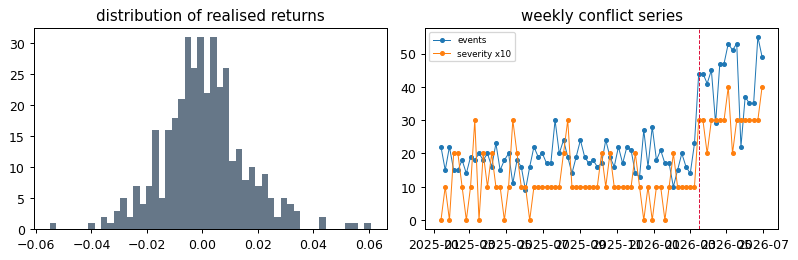

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].hist(ret.dropna(), bins=50, color="#678")
axes[0].set_title("distribution of realised returns")
axes[1].plot(weekly.index, weekly["acled_events"], marker=".", lw=.8, label="events")
axes[1].plot(weekly.index, weekly["hormuz_severity"] * 10, marker=".", lw=.8, label="severity x10")
axes[1].axvline(CONFLICT_ONSET, color="crimson", ls="--", lw=.8)
axes[1].legend(fontsize=7)
axes[1].set_title("weekly conflict series")
plt.tight_layout()

print("skew", round(float(ret.skew()), 4), " kurtosis", round(float(ret.kurtosis()), 4))

In [12]:
with open(f"{REPORTS}/data_audit.txt", "w") as fh:
    print("DATA AUDIT", file=fh)
    print("=" * 70, file=fh)
    print(file=fh)
    print(f"daily  {daily.shape}  {daily.index.min().date()} .. {daily.index.max().date()}", file=fh)
    print(f"weekly {weekly.shape}  {weekly.index.min().date()} .. {weekly.index.max().date()}", file=fh)
    print(file=fh)
    print("master_daily.csv", file=fh)
    print(prof_daily.to_string(index=False), file=fh)
    print(file=fh)
    print("master_weekly.csv", file=fh)
    print(prof_weekly.to_string(index=False), file=fh)
    print(file=fh)
    print("duplicate index values: daily " + str(int(daily.index.duplicated().sum()))
          + ", weekly " + str(int(weekly.index.duplicated().sum())), file=fh)
    print(file=fh)
    print("GRAIN", file=fh)
    print(grain.to_string(index=False), file=fh)

print("wrote", f"{REPORTS}/data_audit.txt")

wrote results/reports/data_audit.txt
